<a href="https://colab.research.google.com/github/rakshitarajan/ML-LAB-2/blob/main/FindS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
FIND-S Algorithm
=================
Learns the maximally specific hypothesis consistent with all positive
training examples. Negative examples are ignored.

Hypothesis notation used here:
    '?'  -> any value is acceptable for this attribute
    '0'  -> no value is acceptable yet (most specific / "not observed")
    'x'  -> a specific required value (e.g. "Sunny")
"""


def find_s(training_data, target_col="EnjoySport", positive_label="Yes"):
    """
    training_data: list of dicts, each representing one training example.
                    Must include the target column.
    Returns: the final hypothesis as a dict {attribute: value}.
    """
    attributes = [a for a in training_data[0].keys() if a != target_col]

    # Step 1: initialize h to the most specific hypothesis
    hypothesis = {attr: "0" for attr in attributes}

    print(f"h0 (initial) : {hypothesis}\n")

    # Step 2 & 3: process each training example
    for i, example in enumerate(training_data, start=1):
        label = example[target_col]

        if label != positive_label:
            print(f"Example {i} ({label}): negative -> ignored")
            continue

        for attr in attributes:
            if hypothesis[attr] == "0":
                # first positive example: adopt its value directly
                hypothesis[attr] = example[attr]
            elif hypothesis[attr] != example[attr]:
                # mismatch -> generalize this attribute
                hypothesis[attr] = "?"
            # else: constraint already satisfied, leave unchanged

        print(f"Example {i} ({label}): positive -> h{i} = {hypothesis}")

    print(f"\nFinal hypothesis: {hypothesis}")
    return hypothesis


if __name__ == "__main__":
    # The classic "EnjoySport" dataset (Tom Mitchell, Machine Learning)
    training_data = [
        {"Sky": "Sunny", "AirTemp": "Warm", "Humidity": "Normal",
         "Wind": "Strong", "Water": "Warm", "Forecast": "Same", "EnjoySport": "Yes"},

        {"Sky": "Sunny", "AirTemp": "Warm", "Humidity": "High",
         "Wind": "Strong", "Water": "Warm", "Forecast": "Same", "EnjoySport": "Yes"},

        {"Sky": "Rainy", "AirTemp": "Cold", "Humidity": "High",
         "Wind": "Strong", "Water": "Warm", "Forecast": "Change", "EnjoySport": "No"},

        {"Sky": "Sunny", "AirTemp": "Warm", "Humidity": "High",
         "Wind": "Strong", "Water": "Cool", "Forecast": "Change", "EnjoySport": "Yes"},
    ]

    final_hypothesis = find_s(training_data)

h0 (initial) : {'Sky': '0', 'AirTemp': '0', 'Humidity': '0', 'Wind': '0', 'Water': '0', 'Forecast': '0'}

Example 1 (Yes): positive -> h1 = {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': 'Normal', 'Wind': 'Strong', 'Water': 'Warm', 'Forecast': 'Same'}
Example 2 (Yes): positive -> h2 = {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': '?', 'Wind': 'Strong', 'Water': 'Warm', 'Forecast': 'Same'}
Example 3 (No): negative -> ignored
Example 4 (Yes): positive -> h4 = {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': '?', 'Wind': 'Strong', 'Water': '?', 'Forecast': '?'}

Final hypothesis: {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': '?', 'Wind': 'Strong', 'Water': '?', 'Forecast': '?'}


Step-by-step hypothesis:
  h0: {'Sky': '0', 'AirTemp': '0', 'Humidity': '0', 'Wind': '0', 'Water': '0', 'Forecast': '0'}
  h1: {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': 'Normal', 'Wind': 'Strong', 'Water': 'Warm', 'Forecast': 'Same'}
  h2: {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': '?', 'Wind': 'Strong', 'Water': 'Warm', 'Forecast': 'Same'}
  Ex3 (neg): {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': '?', 'Wind': 'Strong', 'Water': 'Warm', 'Forecast': 'Same'}
  h4: {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': '?', 'Wind': 'Strong', 'Water': '?', 'Forecast': '?'}

Final hypothesis: {'Sky': 'Sunny', 'AirTemp': 'Warm', 'Humidity': '?', 'Wind': 'Strong', 'Water': '?', 'Forecast': '?'}


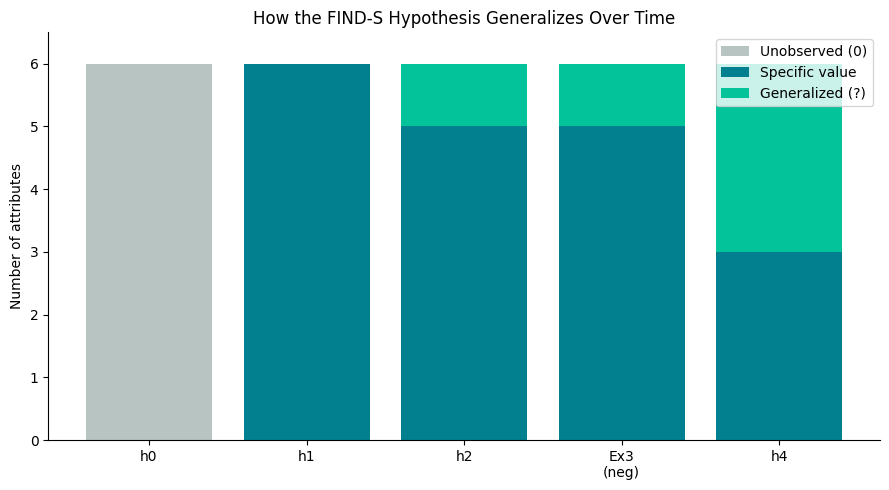

Saved: specificity_trend.png


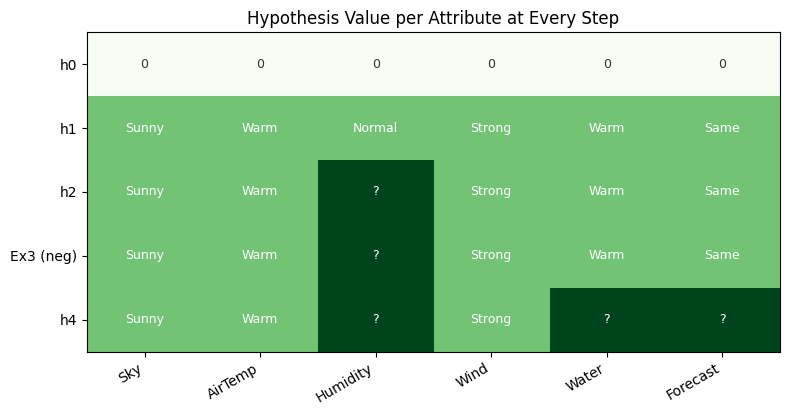

Saved: hypothesis_heatmap.png


In [ ]:
"""
FIND-S Algorithm with Visual Analysis
======================================
Runs FIND-S on the classic "EnjoySport" dataset, keeps a full history of the
hypothesis after every training example, then plots:

  1. Specificity trend  -> stacked bar chart: how many attributes are
     unobserved / specific / generalized ("?") at each step.
  2. Hypothesis heatmap -> attribute-by-step grid showing exactly which
     attribute changed and when.

Hypothesis notation used here:
    '0'  -> no value accepted yet (most specific / "not observed")
    '?'  -> any value accepted (fully general)
    'x'  -> a specific required value (e.g. "Sunny")
"""

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# 1. FIND-S core algorithm (returns full step-by-step history)
# ----------------------------------------------------------------------
def find_s_with_history(training_data, target_col="EnjoySport", positive_label="Yes"):
    attributes = [a for a in training_data[0].keys() if a != target_col]
    hypothesis = {attr: "0" for attr in attributes}

    # history entries: (label_for_x_axis, hypothesis_snapshot, was_positive)
    history = [("h0", dict(hypothesis), None)]

    for i, example in enumerate(training_data, start=1):
        label = example[target_col]

        if label != positive_label:
            history.append((f"Ex{i}\n(neg)", dict(hypothesis), False))
            continue

        for attr in attributes:
            if hypothesis[attr] == "0":
                hypothesis[attr] = example[attr]
            elif hypothesis[attr] != example[attr]:
                hypothesis[attr] = "?"

        history.append((f"h{i}", dict(hypothesis), True))

    return hypothesis, history, attributes


# ----------------------------------------------------------------------
# 2. Plot: specificity trend (stacked bar chart)
# ----------------------------------------------------------------------
def plot_specificity_trend(history, attributes, save_as="specificity_trend.png"):
    steps = [h[0] for h in history]
    unobserved, specific, general = [], [], []

    for _, hyp, _ in history:
        g = sum(1 for v in hyp.values() if v == "?")
        u = sum(1 for v in hyp.values() if v == "0")
        s = len(attributes) - g - u
        unobserved.append(u)
        specific.append(s)
        general.append(g)

    x = np.arange(len(steps))
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(x, unobserved, label="Unobserved (0)", color="#B7C4C2")
    ax.bar(x, specific, bottom=unobserved, label="Specific value", color="#028090")
    bottom2 = np.array(unobserved) + np.array(specific)
    ax.bar(x, general, bottom=bottom2, label="Generalized (?)", color="#02C39A")

    ax.set_xticks(x)
    ax.set_xticklabels(steps)
    ax.set_ylabel("Number of attributes")
    ax.set_title("How the FIND-S Hypothesis Generalizes Over Time")
    ax.set_ylim(0, len(attributes) + 0.5)
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_as, dpi=150)
    plt.show()
    print(f"Saved: {save_as}")


# ----------------------------------------------------------------------
# 3. Plot: hypothesis evolution heatmap
# ----------------------------------------------------------------------
def plot_hypothesis_heatmap(history, attributes, save_as="hypothesis_heatmap.png"):
    # encode: 0 = unobserved, 1 = specific, 2 = general(?)
    grid = []
    for _, hyp, _ in history:
        row = [0 if hyp[a] == "0" else (2 if hyp[a] == "?" else 1) for a in attributes]
        grid.append(row)
    grid = np.array(grid)

    fig, ax = plt.subplots(figsize=(8, 0.55 * len(history) + 1.5))
    im = ax.imshow(grid, cmap="Greens", aspect="auto", vmin=0, vmax=2)

    ax.set_xticks(range(len(attributes)))
    ax.set_xticklabels(attributes, rotation=30, ha="right")
    ax.set_yticks(range(len(history)))
    ax.set_yticklabels([h[0].replace("\n", " ") for h in history])

    for i, (_, hyp, _) in enumerate(history):
        for j, attr in enumerate(attributes):
            color = "white" if grid[i, j] >= 1 else "#333333"
            ax.text(j, i, hyp[attr], ha="center", va="center", fontsize=9, color=color)

    ax.set_title("Hypothesis Value per Attribute at Every Step")
    plt.tight_layout()
    plt.savefig(save_as, dpi=150)
    plt.show()
    print(f"Saved: {save_as}")


# ----------------------------------------------------------------------
# 4. Run everything on the EnjoySport dataset
# ----------------------------------------------------------------------
if __name__ == "__main__":
    training_data = [
        {"Sky": "Sunny", "AirTemp": "Warm", "Humidity": "Normal",
         "Wind": "Strong", "Water": "Warm", "Forecast": "Same", "EnjoySport": "Yes"},

        {"Sky": "Sunny", "AirTemp": "Warm", "Humidity": "High",
         "Wind": "Strong", "Water": "Warm", "Forecast": "Same", "EnjoySport": "Yes"},

        {"Sky": "Rainy", "AirTemp": "Cold", "Humidity": "High",
         "Wind": "Strong", "Water": "Warm", "Forecast": "Change", "EnjoySport": "No"},

        {"Sky": "Sunny", "AirTemp": "Warm", "Humidity": "High",
         "Wind": "Strong", "Water": "Cool", "Forecast": "Change", "EnjoySport": "Yes"},
    ]

    final_hypothesis, history, attributes = find_s_with_history(training_data)

    print("Step-by-step hypothesis:")
    for label, hyp, _ in history:
        print(f"  {label.replace(chr(10), ' ')}: {hyp}")
    print(f"\nFinal hypothesis: {final_hypothesis}")

    plot_specificity_trend(history, attributes)
    plot_hypothesis_heatmap(history, attributes)